In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("1632300362534233.csv")
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


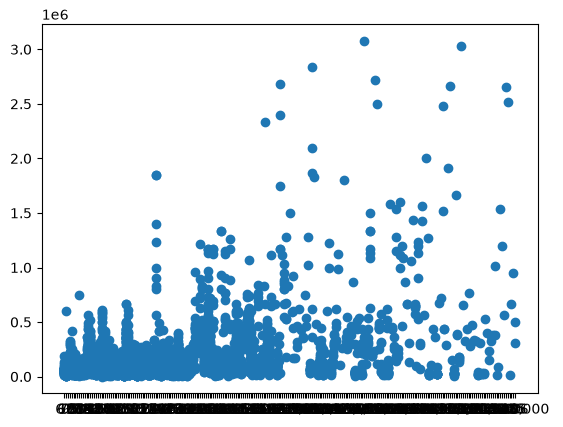

In [3]:
plt.scatter(df.Area, df["Price(USD)"])

In [4]:
df.Address.value_counts()

Address
Punak                     161
Pardis                    146
West Ferdows Boulevard    145
Gheitarieh                141
Shahran                   130
                         ... 
Firoozkooh                  1
Shadabad                    1
Naziabad                    1
Javadiyeh                   1
Yakhchiabad                 1
Name: count, Length: 192, dtype: int64

In [5]:
sorted(df.Area.value_counts())

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 9,
 9,
 9,
 9,
 9,
 10,
 10,
 10,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 12,
 13,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 14,
 15,
 15,
 15,
 16,
 16,
 17,
 17,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 20,
 20,
 20,
 21,
 21,
 22,
 22,
 23,
 23,
 23,
 24,
 24,
 24,
 25,
 25,
 27,
 27,
 27,
 27,
 29,
 29,
 29,
 29,
 31,
 31,
 31,
 34,
 36,
 36,
 39,
 40,
 40,
 41,
 41,
 44,
 44,
 45,
 45,
 47,
 47,
 49,
 51,
 51,
 52,
 54,

In [6]:
from sklearn.preprocessing import LabelEncoder

df["Parking"] = LabelEncoder().fit_transform(df["Parking"])
df["Warehouse"] = LabelEncoder().fit_transform(df["Warehouse"])
df["Elevator"] = LabelEncoder().fit_transform(df["Elevator"])
df["Address"] = LabelEncoder().fit_transform(df["Address"])
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df = df.dropna()
df = df.reset_index(drop=True)

df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63.0,1,1,1,1,156,1.850000e+09,61666.67
1,60.0,1,1,1,1,156,1.850000e+09,61666.67
2,79.0,2,1,1,1,117,5.500000e+08,18333.33
3,95.0,2,1,1,1,152,9.025000e+08,30083.33
4,123.0,2,1,1,1,150,7.000000e+09,233333.33


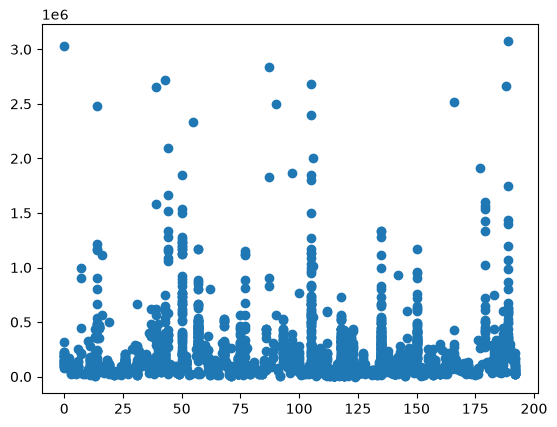

In [7]:
plt.scatter(df.Address, df["Price(USD)"])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = np.asanyarray(df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]])
y = np.asanyarray(df["Price(USD)"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

print("--------------------------------------")
print(X_train)
print("--------------------------------------")
print(y_train)
print("--------------------------------------")

--------------------------------------
[[ 86.   2.   1.   1.   1.  12.]
 [108.   2.   1.   1.   0. 115.]
 [240.   4.   1.   1.   0.  13.]
 ...
 [ 97.   2.   1.   1.   1. 122.]
 [236.   4.   1.   1.   1.  57.]
 [ 75.   2.   1.   1.   1. 106.]]
--------------------------------------
[ 66000.    38333.33 190000.   ... 156666.67 666666.67  97666.67]
--------------------------------------


In [9]:
from sklearn.linear_model import LinearRegression

lmodel = LinearRegression()

lmodel.fit(X_train, y_train)

yhat = lmodel.predict(X_test)

In [10]:
print(yhat[:5])
print(y_test[:5])

[279899.16000853 135013.98119667 367094.60267862 240231.98393837
  92153.89110519]
[173333.33 118333.33 533333.33 105666.67  53333.33]


In [11]:
from sklearn.metrics import r2_score

score = r2_score(y_test, yhat)
print(score)

0.5221282738362101
